# This notebook is used to visualy inspect the quality of the ground truths and the proposed regions of interest RoI for the masked R-CNN

In [1]:
dataset_filepath = "/net/vdesk/data2/penchev/project_data/b2s_masked_rcnn_test/"
images_train_filepath = "images"
proposals_train_filepath = "proposals"
annotations_path = "annotations.json"

# Load the json file containing the cutout metadata and proposed RoIs

In [2]:
import json
import os

annotations_path = os.path.join(dataset_filepath, annotations_path)
with open(annotations_path, "r") as f:
    annotations = json.load(f)

# Show the structure of the annotations (COCO format)
for key in annotations.keys():
    key_type = type(annotations[key])
    element_type = type(annotations[key][0]) if isinstance(annotations[key], list) and len(annotations[key]) > 0 else None
    print(f"{key}: {key_type}, element type: {element_type}, length: {len(annotations[key])}")
    if element_type == dict:
        for key2 in annotations[key][0].keys():
            key2_type = type(annotations[key][0][key2])
            element2_type = type(annotations[key][0][key2][0]) if isinstance(annotations[key][0][key2], list) and len(annotations[key][0][key2]) > 0 else None
            print(f"  {key2}: {key2_type}")
            if key2 == "metadata":
                for key3 in annotations[key][0][key2].keys():
                    key3_type = type(annotations[key][0][key2][key3])
                    print(f"    {key3}: {key3_type}")

images: <class 'list'>, element type: <class 'dict'>, length: 784
  id: <class 'int'>
  file_name: <class 'str'>
  width: <class 'int'>
  height: <class 'int'>
  metadata: <class 'dict'>
    RA: <class 'float'>
    DEC: <class 'float'>
    candidates: <class 'dict'>
    rotated: <class 'bool'>
    origin_id: <class 'int'>
    rotation_angle: <class 'int'>
    stretch: <class 'str'>
    reprojected: <class 'bool'>
    old_redshift: <class 'NoneType'>
    new_redshift: <class 'NoneType'>
annotations: <class 'list'>, element type: <class 'dict'>, length: 4710
  id: <class 'int'>
  image_id: <class 'int'>
  category_id: <class 'int'>
  bbox: <class 'list'>
  area: <class 'float'>
  segmentation: <class 'dict'>
  iscrowd: <class 'int'>
  instance_positions: <class 'list'>
categories: <class 'list'>, element type: <class 'dict'>, length: 2
  id: <class 'int'>
  name: <class 'str'>


In [3]:
print(annotations["annotations"][0])

{'id': 1, 'image_id': 1, 'category_id': 1, 'bbox': [118.0, 129.0, 180.0, 167.0], 'area': 1301.0, 'segmentation': {'size': [300, 300], 'counts': 'ofR14S97N1O1N1O1N3O100OO1O01EAiG`0V8AiGc0S8^OlGb0U8]OkG=LCY80kG?K_O\\81iGc0X8]OfGd0[8600OL6O0\\O^G>h81O0ON4N3N001OIE]G;b8H[G:e874K1O01DBhG>X8BhG?W8AhGa0U8AkGa0R8BlG?S8AmG`0S8_OmGc0R8\\OnGd0R8^OkGc0U8^OjGc0U8XOlGl0U8TOkGg0Y8YOiGe0W8\\OhGc0Z8]OeGc0^841N4L2O1O1N100N203L3LRgR1'}, 'iscrowd': 0, 'instance_positions': [[150, 150]]}


# Display the images with the proposed RoIs and ground truth annotations

In [11]:
import matplotlib.pyplot as plt
from pycocotools.coco import COCO
import numpy as np
import os

def get_image_by_id(annotations: dict, image_id: int) -> dict:
    """
    Retrieve the image element from the annotations JSON by image ID.
    
    :param annotations: The annotations dictionary containing 'images' list
    :param image_id: The ID of the image to find
    :return: Dictionary containing image metadata (id, file_name, width, height, metadata)
    :raises ValueError: If image_id is not found
    """
    for image in annotations['images']:
        if image['id'] == image_id:
            return image
    raise ValueError(f"Image with id {image_id} not found in annotations")

def plot_image_with_boxes_proposals(annotations: dict, annotations_path: str, id: int):
    """
    Plot an image with bounding boxes overlaid.
    
    :param image_path: Path to the image file
    :param boxes: Array of bounding boxes in the format [x_min, y_min, x_max, y_max]
    """
    image_info = get_image_by_id(annotations, id)
    image_file_name = image_info['file_name']
    proposals = image_file_name.replace(".png", ".npz")
    image_path = os.path.join(dataset_filepath, images_train_filepath, image_file_name)
    proposals_path = os.path.join(dataset_filepath, proposals_train_filepath, proposals)

    # Get the data for the plotting of the images
    proposal_boxes = np.load(proposals_path)['boxes']

    components = image_info['metadata']['candidates']['grouping']['components']
    sources = image_info['metadata']['candidates']['grouping']['sources']

    # Load COCO annotations
    coco = COCO(annotations_path)
    ann_ids = coco.getAnnIds(imgIds=[id], iscrowd=None)
    anns = coco.loadAnns(ann_ids)
    
    # COCO format: [x_min, y_min, x_max, y_max]
    # (x_min, y_min) is the top-left corner
    # (x_max, y_max) is the bottom-right corner
    gt_boxes = [ann['bbox'] for ann in anns]
    
    # Get segmentation masks
    segs = [ann['segmentation'] for ann in anns]

    # Get positions of the components in the GT box
    instance_positions = [ann['instance_positions'] for ann in anns]

    # Get category IDs
    category_ids = [ann['category_id'] for ann in anns]

    SCS_color = 'cyan'  # category id 1
    MCS_color = 'red'   # category id 2
    
    # Get component positions
    grg_positions = image_info['metadata'].get('grg_positions', [])
    all_component_positions = image_info['metadata'].get('all_component_positions', [])
    
    fig, ax = plt.subplots(1, 2, figsize=(16, 8))

    img = plt.imread(image_path)
    
    # Plot GT boxes and segmentation on ax[0]
    ax[0].imshow(img)
    for i, box in enumerate(gt_boxes):
        x_min, y_min, x_max, y_max = box
        width = x_max - x_min
        height = y_max - y_min
        edgecolor = SCS_color if category_ids[i] == 1 else MCS_color
        rect = plt.Rectangle((x_min, y_min), width, height, edgecolor=edgecolor, facecolor='none', linewidth=2)
        ax[0].add_patch(rect)

    for i, seg in enumerate(segs):
        if isinstance(seg, list):  # Polygon segmentation
            print(f"Polygon segmentation with {len(seg)} polygons")
            for polygon in seg:
                poly = np.array(polygon).reshape((-1, 2))
                ax[0].fill(poly[:, 0], poly[:, 1], alpha=0.3, color='black')

        if isinstance(seg, dict) and 'counts' in seg:  # RLE segmentation
            print("RLE segmentation found")
            mask = coco.annToMask(anns[i])  # Get binary mask from current annotation RLE
            seg_color = SCS_color if category_ids[i] == 1 else MCS_color
            masked = np.ma.masked_where(mask == 0, mask)
            cmap = plt.get_cmap('Oranges_r') if seg_color == MCS_color else plt.get_cmap('Blues_r')
            ax[0].imshow(masked, alpha=0.8, cmap=cmap)

    for i, ip in enumerate(instance_positions):
        color = SCS_color if category_ids[i] == 1 else MCS_color
        for pos in ip:
            ax[0].annotate(f"{i}", tuple(pos), color=color, fontsize=15, ha='center')

    ax[0].set_title("GT Boxes and Segmentation")

    ax[1].imshow(img)
    print(f"Plotting {len(proposal_boxes)} proposal boxes on image {image_file_name}")

    # First find the box with the biggest overlap with GT boxes
    iou_scores = []
    gt_x_min, gt_y_min, gt_x_max, gt_y_max = gt_boxes[0]  # Assuming one GT box for simplicity
    gt_width = gt_x_max - gt_x_min
    gt_height = gt_y_max - gt_y_min
    gt_box_area = gt_width * gt_height

    for box in proposal_boxes:
        # Get the proposal box coordinates
        x_min, y_min, x_max, y_max = box
        width = x_max - x_min
        height = y_max - y_min

        # Calculate intersection
        inter_x_min = max(x_min, gt_x_min)
        inter_y_min = max(y_min, gt_y_min)
        inter_x_max = min(x_max, gt_x_max)
        inter_y_max = min(y_max, gt_y_max)
        inter_width = max(0, inter_x_max - inter_x_min)
        inter_height = max(0, inter_y_max - inter_y_min)
        intersection = inter_width * inter_height

        # Calculate union
        box_area = width * height
        union = box_area + gt_box_area - intersection
        iou = intersection / union if union > 0 else 0

        iou_scores.append(iou)

    iou_scores_arr = np.array(iou_scores)
    best_box_idx = np.argmax(iou_scores_arr)
    print(f"Best box index: {best_box_idx}, IoU: {iou_scores_arr[best_box_idx]:.4f}")

    for i, box in enumerate(proposal_boxes):
        x_min, y_min, x_max, y_max = box
        width = x_max - x_min
        height = y_max - y_min
        rect = plt.Rectangle((x_min, y_min), width, height, edgecolor='red', facecolor='none', linewidth=2, label='Proposed Box' if i == 0 else "")
        ax[1].add_patch(rect)

    # Plot the best box in green
    best_box = proposal_boxes[best_box_idx]
    x_min, y_min, x_max, y_max = best_box
    width = x_max - x_min
    height = y_max - y_min
    rect = plt.Rectangle((x_min, y_min), width, height, edgecolor='green', facecolor='none', linewidth=2, label='Best Box')
    ax[1].add_patch(rect)

    ax[1].set_title("Image with Bounding Boxes")
    plt.legend()
    plt.show()

loading annotations into memory...
Done (t=0.10s)
creating index...
index created!
RLE segmentation found
RLE segmentation found
RLE segmentation found
RLE segmentation found
RLE segmentation found
RLE segmentation found
RLE segmentation found
Plotting 127 proposal boxes on image LoTSS_B2S_MaskRCNN_0000000085_rotated_angle90_RA1.623899_DEC32.766689.png
Best box index: 0, IoU: 1.0000


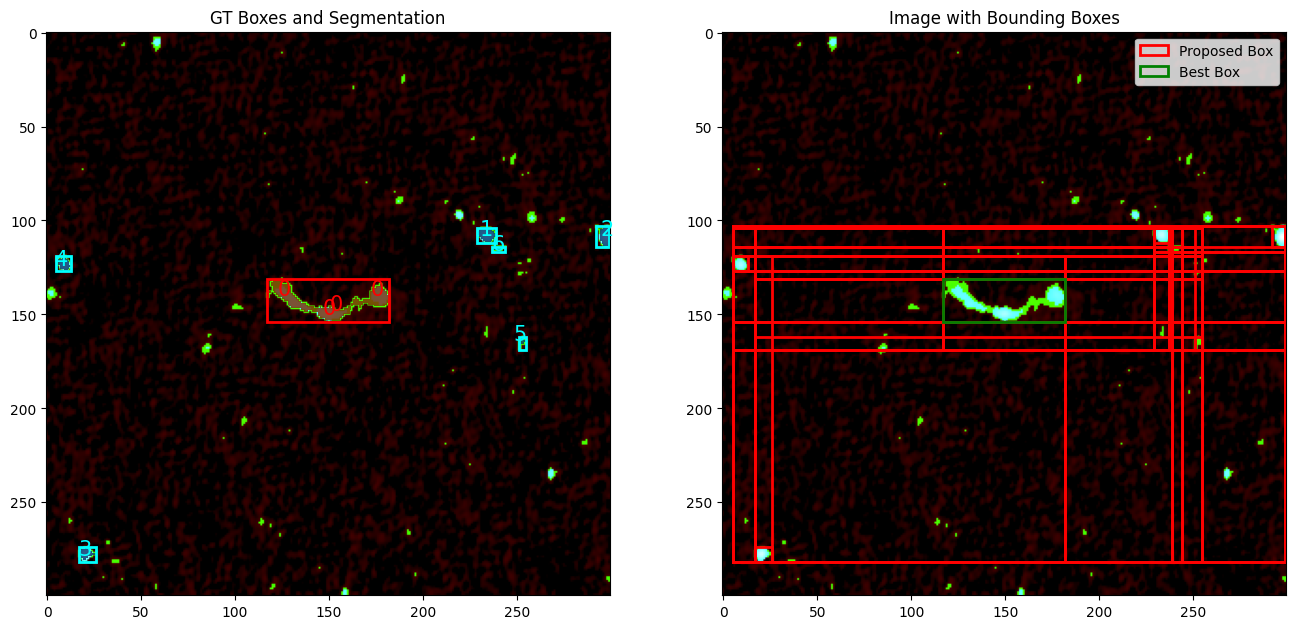

loading annotations into memory...
Done (t=0.09s)
creating index...
index created!
RLE segmentation found
RLE segmentation found
RLE segmentation found
RLE segmentation found
RLE segmentation found
RLE segmentation found
RLE segmentation found
Plotting 127 proposal boxes on image LoTSS_B2S_MaskRCNN_0000000081_rotated_angle45_RA1.623899_DEC32.766689.png
Best box index: 0, IoU: 1.0000


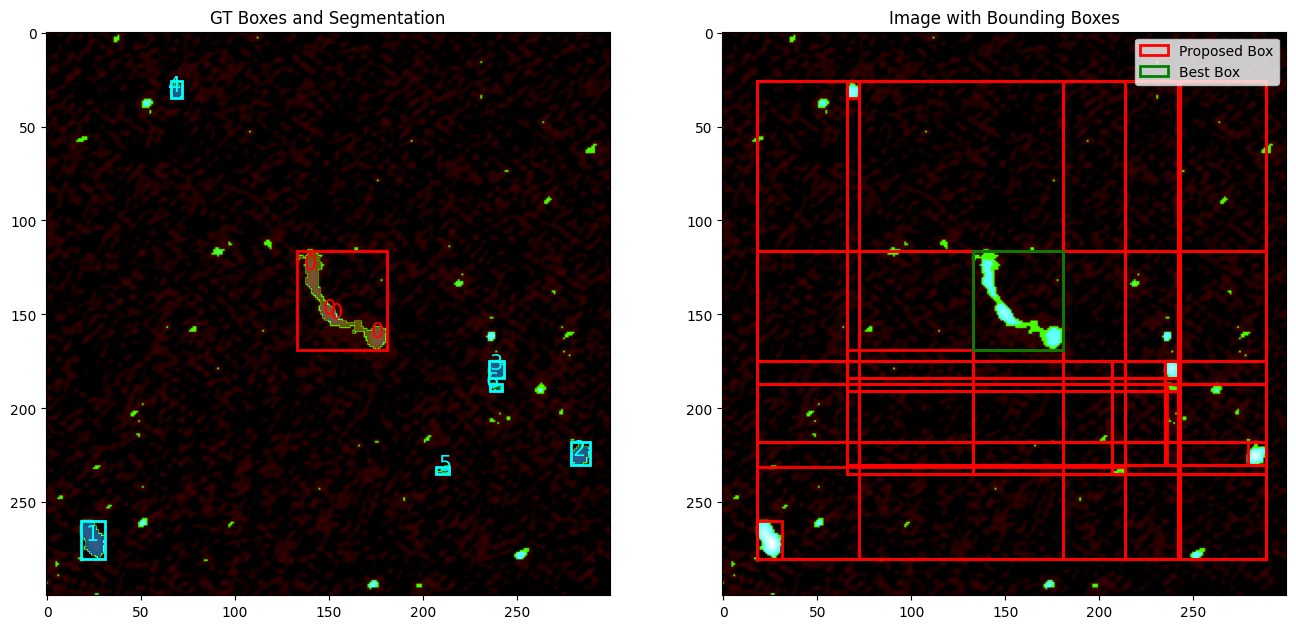

loading annotations into memory...
Done (t=0.20s)
creating index...
index created!
RLE segmentation found
RLE segmentation found
RLE segmentation found
RLE segmentation found
RLE segmentation found
RLE segmentation found
RLE segmentation found
RLE segmentation found
Plotting 255 proposal boxes on image LoTSS_B2S_MaskRCNN_0000000050_rotated_angle180_RA0.427086_DEC26.102713.png
Best box index: 0, IoU: 1.0000


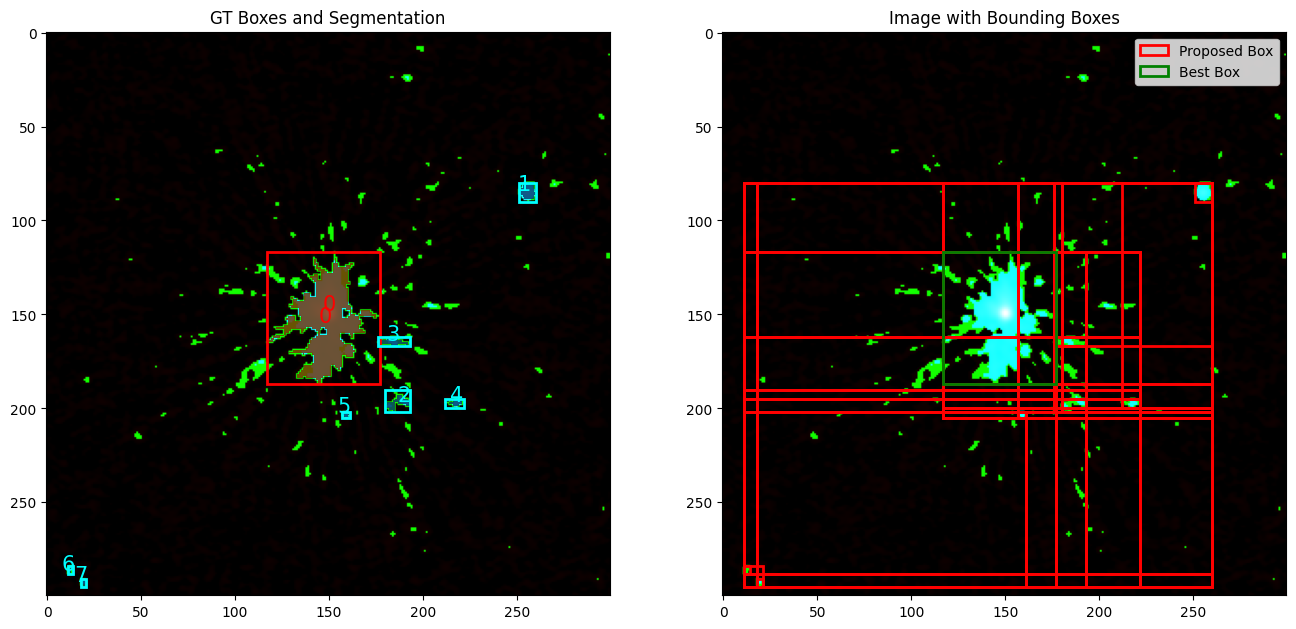

loading annotations into memory...
Done (t=0.22s)
creating index...
index created!
RLE segmentation found
RLE segmentation found
RLE segmentation found
RLE segmentation found
RLE segmentation found
RLE segmentation found
RLE segmentation found
Plotting 511 proposal boxes on image LoTSS_B2S_MaskRCNN_0000000076_rotated_angle180_RA2.588217_DEC34.257863.png
Best box index: 3, IoU: 1.0000


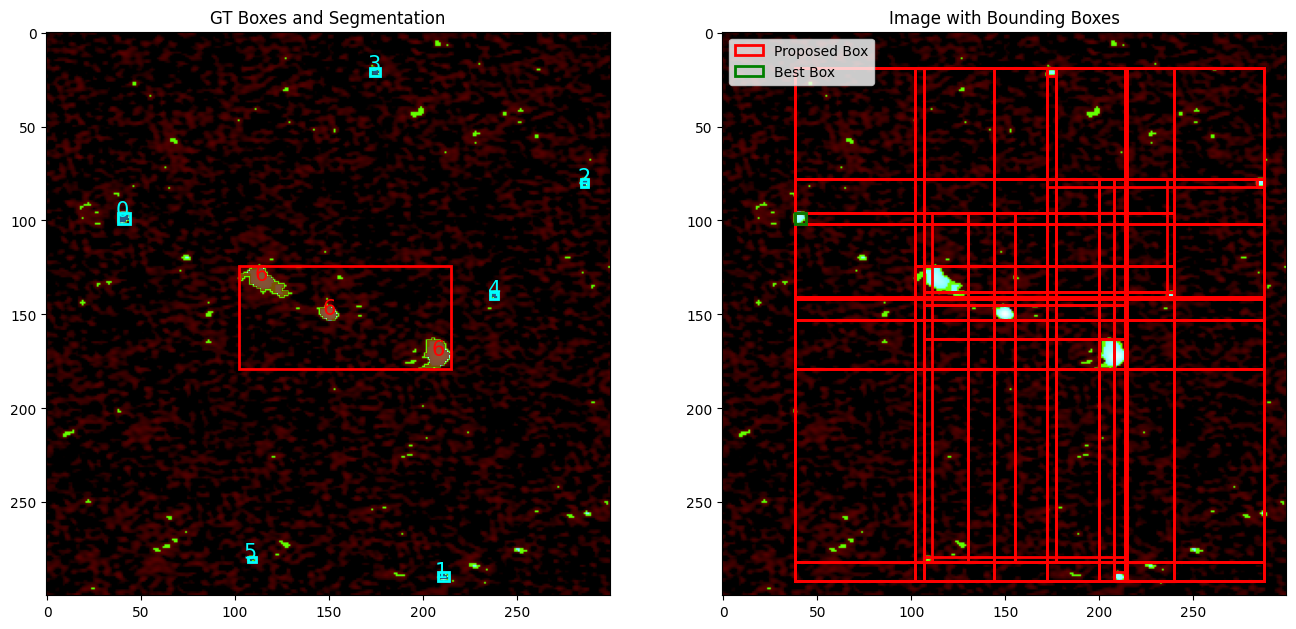

loading annotations into memory...
Done (t=0.08s)
creating index...
index created!
RLE segmentation found
RLE segmentation found
RLE segmentation found
RLE segmentation found
RLE segmentation found
Plotting 31 proposal boxes on image LoTSS_B2S_MaskRCNN_0000000082_rotated_angle270_RA2.606785_DEC33.49356.png
Best box index: 0, IoU: 1.0000


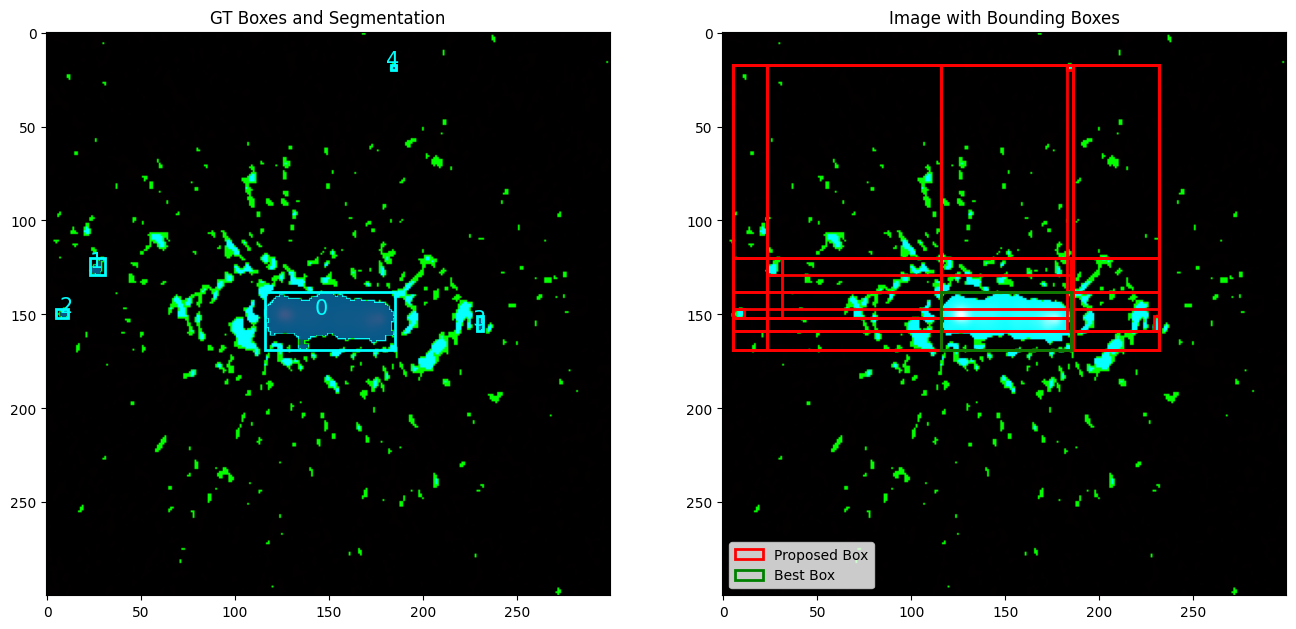

loading annotations into memory...
Done (t=0.21s)
creating index...
index created!
RLE segmentation found
RLE segmentation found
RLE segmentation found
RLE segmentation found
RLE segmentation found
Plotting 255 proposal boxes on image LoTSS_B2S_MaskRCNN_0000000091_rotated_angle45_RA1.607026_DEC21.472013.png
Best box index: 0, IoU: 1.0000


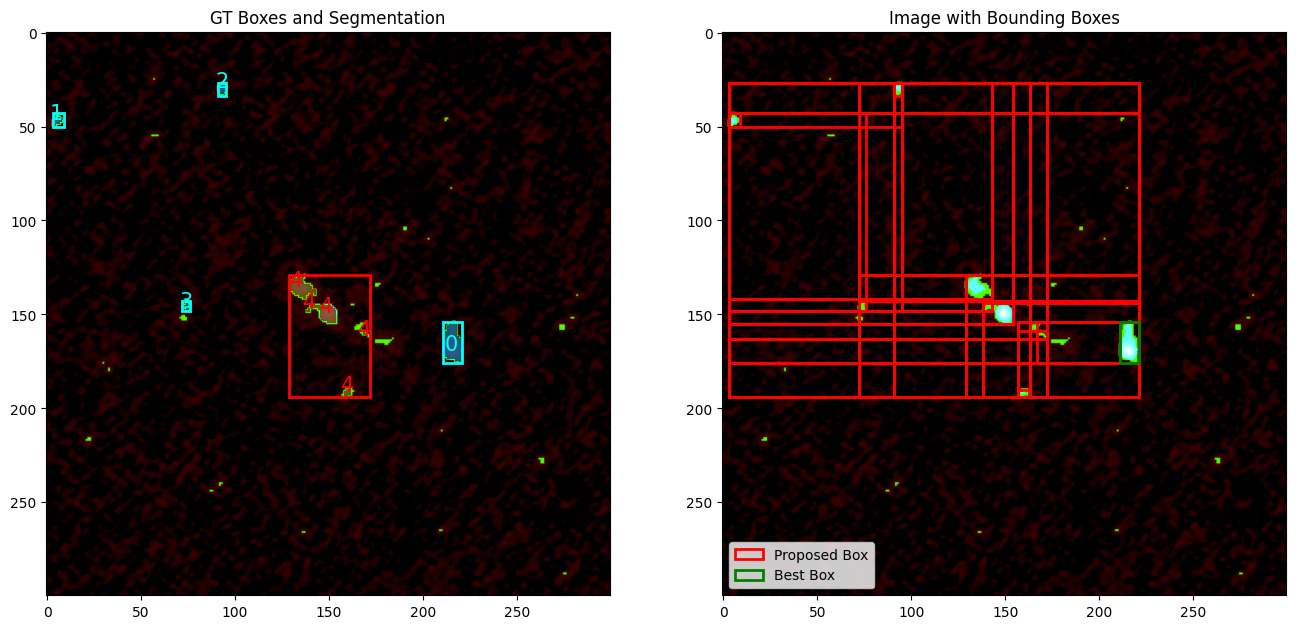

loading annotations into memory...
Done (t=0.20s)
creating index...
index created!
RLE segmentation found
RLE segmentation found
RLE segmentation found
RLE segmentation found
RLE segmentation found
RLE segmentation found
Plotting 63 proposal boxes on image LoTSS_B2S_MaskRCNN_0000000031_RA0.28152_DEC23.87971.png
Best box index: 0, IoU: 1.0000


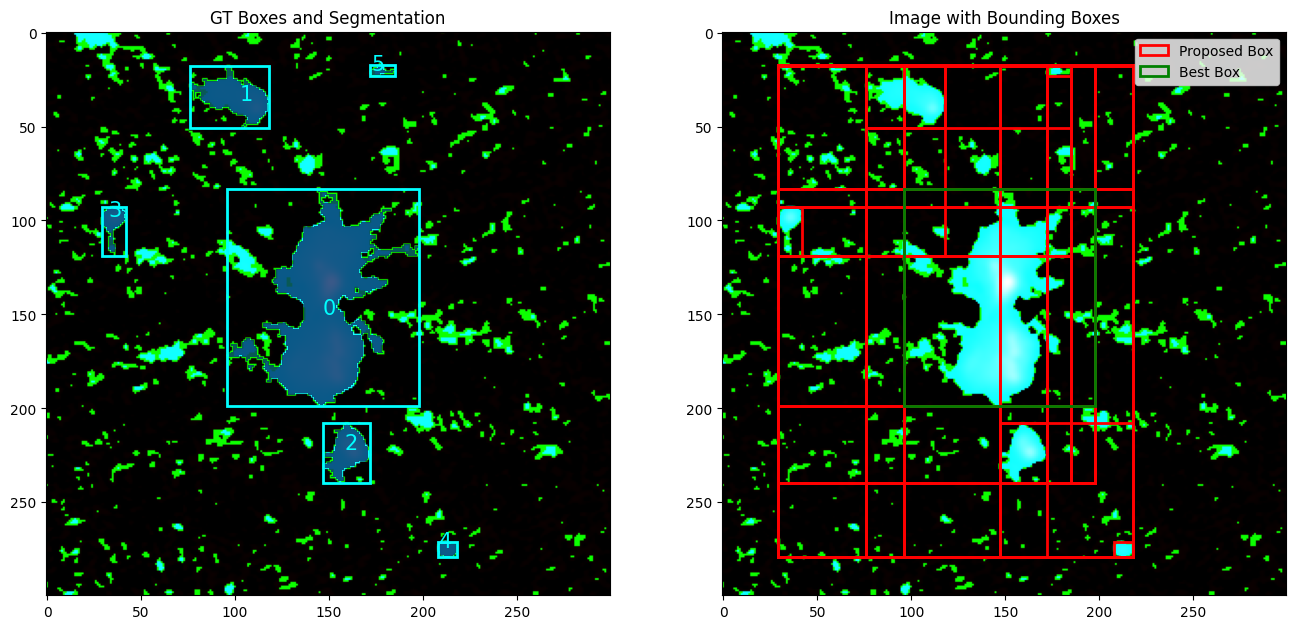

loading annotations into memory...
Done (t=0.20s)
creating index...
index created!
RLE segmentation found
RLE segmentation found
RLE segmentation found
RLE segmentation found
Plotting 63 proposal boxes on image LoTSS_B2S_MaskRCNN_0000000011_rotated_angle45_RA0.524864_DEC33.061545.png
Best box index: 2, IoU: 1.0000


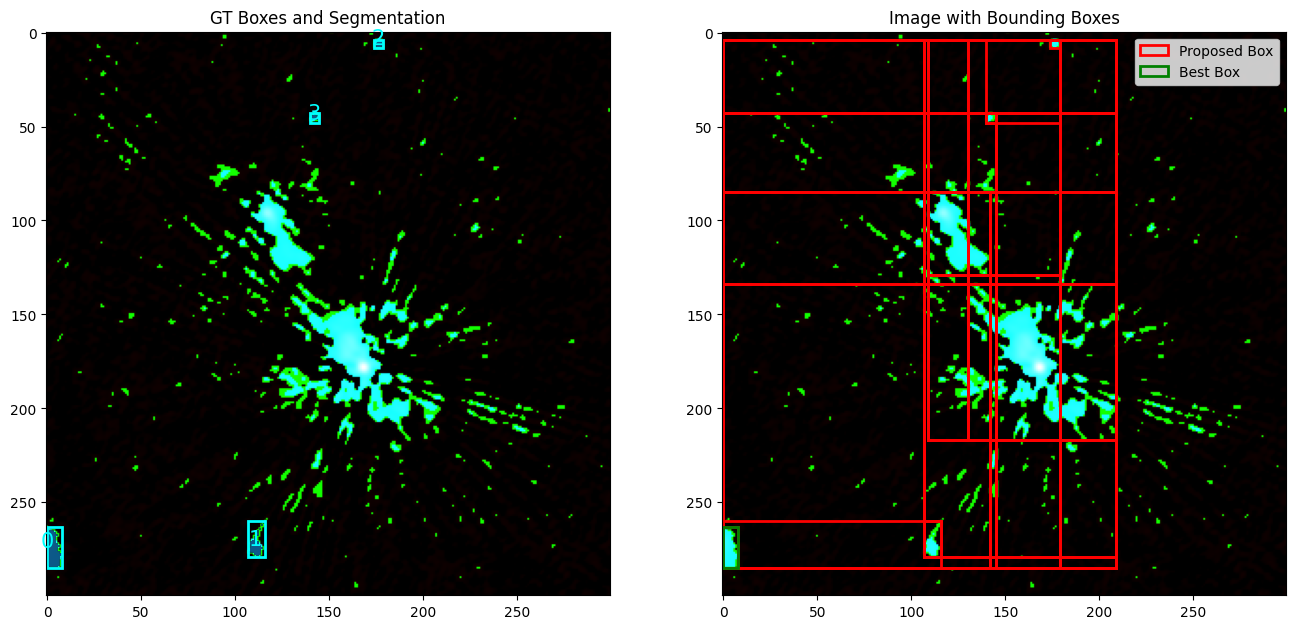

In [12]:
# Generate 8 random numbers from 0-7000
import random
random_ids = random.sample(range(100), 8)
for i in random_ids:
    plot_image_with_boxes_proposals(annotations, annotations_path, i)